# **Regressão Linear Simples**

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.linear_model import LinearRegression
from yellowbrick.regressor import ResidualsPlot

DRIVE_DIRECTORY = Path.cwd().parent / "data"

## Base plano saúde

In [2]:
base_plano_saude = pd.read_csv(os.path.join(DRIVE_DIRECTORY, "plano_saude.csv"))
base_plano_saude

,idade,custo
0,18,871
1,23,1132
2,28,1242
3,33,1356
4,38,1488
5,43,1638
6,48,2130
7,53,2454
8,58,3066
9,63,4090


In [3]:
X_plano_saude = base_plano_saude.iloc[:, 0].values
y_plano_saude = base_plano_saude.iloc[:, 1].values
X_plano_saude

array([18, 23, 28, 33, 38, 43, 48, 53, 58, 63])

In [4]:
np.corrcoef(X_plano_saude, y_plano_saude)

array([[1.        , 0.93091958],
       [0.93091958, 1.        ]])

In [5]:
X_plano_saude.shape

(10,)

In [6]:
X_plano_saude = X_plano_saude.reshape(-1, 1)
X_plano_saude.shape

(10, 1)

In [7]:
regressor_plano_saude = LinearRegression()
regressor_plano_saude.fit(X_plano_saude, y_plano_saude)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
# B0
regressor_plano_saude.intercept_

np.float64(-558.9490909090912)

In [9]:
#b1
regressor_plano_saude.coef_

array([61.86787879])

In [10]:
previsoes = regressor_plano_saude.predict(X_plano_saude)
previsoes

array([ 554.67272727,  864.01212121, 1173.35151515, 1482.69090909,
       1792.03030303, 2101.36969697, 2410.70909091, 2720.04848485,
       3029.38787879, 3338.72727273])

In [11]:
grafico = px.scatter(x=X_plano_saude.ravel(), y=y_plano_saude)
grafico.add_scatter(x=X_plano_saude.ravel(), y=previsoes, name='Regressão')
grafico.show()

In [12]:
regressor_plano_saude.score(X_plano_saude, y_plano_saude)

0.8666112727879174

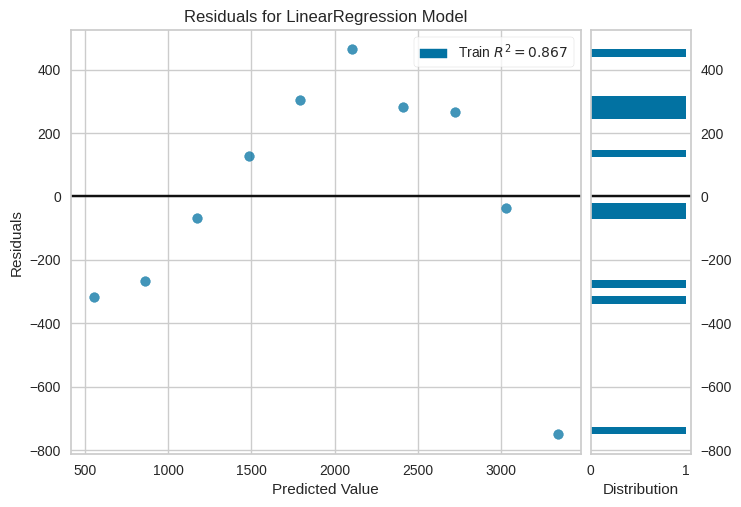

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [13]:
visualizador = ResidualsPlot(regressor_plano_saude, force_model=True)
visualizador.fit(X_plano_saude, y_plano_saude)
visualizador.poof()

## Base preço das casas

# **Regressão Linear Múltipla**